In [ ]:
import pandas as pd
from datasets import Dataset, load_from_disk
from collections import Counter
import matplotlib.pyplot as plt
import textstat
import spacy
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from edm import report

In [6]:
base_path = "/mnt/vast-kisski/projects/kisski_tegami"
INPUT_PATH = f"{base_path}"
OUTPUT_PATH = f"{base_path}"
DATASETS = ["CMSB", "hateXplain", "SemEval2017", "BABE"]

### Utils

In [7]:
def load_testset(dataset_name: str) -> Dataset:
    """
    Loads the test split of a dataset from disk and ensures it has at least 1000 examples.

    Args:
        dataset (str): The name of the dataset directory to load from.

    Returns:
        Dataset: The 'test' split of the loaded dataset.
    """
    dataset_path = f"{INPUT_PATH}/datasets/{dataset_name}"
    print(f"\nLoad Dataset from {dataset_path}")
    ds_dict = load_from_disk(dataset_path)
    ds_test = ds_dict["test"]

    assert len(ds_test) >= 1000
    return ds_test

# Perplexity
NLP = spacy.load("en_core_web_sm")
def tokenize_and_lemmatize(text: str):
    doc = NLP(text)
    return [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]

def lexical_entropy(text: str) -> float:
    """
    Compute entropy of a text based on token distribution.
    """

    # Preprocess
    tokens = tokenize_and_lemmatize(text)


    n = len(tokens)
    if n == 0:
        return 0.0

    # Word frequencies
    freqs = Counter(tokens)
    probs = np.array(list(freqs.values())) / n

    # Shannon entropy (base 2)
    entropy = -np.sum(probs * np.log2(probs))
    return entropy


def lexical_perplexity(text: str) -> float:
    """
    Compute perplexity from entropy.
    """
    H = lexical_entropy(text)
    return 2 ** H


## Test
https://github.com/Wluper/edm/tree/master

In [ ]:

for dataset_name in DATASETS:
    ds = load_testset(dataset_name)
    df = ds.to_pandas()
    sents = df["text"].to_list()
    labels = df["label_text"].to_list()
    print(dataset_name)
    print(report.get_difficulty_report(sents, labels))


Load Dataset from /mnt/vast-kisski/projects/kisski_tegami/datasets/CMSB
CMSB
----> Building bag of words representations...
[-----------                   ] : 946 of 2668, 35.5% : Est. 0.0 mins Remaining

[-------------------------------] : 2667 of 2668, 100.0% : Est. 0.0 mins Remaining: 2037 of 2668, 76.3% : Est. 0.0 mins Remaining
----> Done.
----> Getting difficulty metrics...
----> Done.
----> Getting generic statistics...
----> Done.


Dataset Size                 2668                -
Vocab Size                   7221                -
Number of Classes            2                   -
Mean Items Per Class         1334.0              -
Min. Items in a Class        361                 SLIGHTLY LOW
Average Sentence Length      84.2372563718141    -
Distinct Words : Total Words 0.18917502816274134 VERY HIGH
Class Imbalance              0.7293853073463268  SOMEWHAT HIGH
Class Diversity              0.39635263808310817 GOOD
Max. Hellinger Similarity    0.5290627511665826  GOOD
Mutual Information           1.5204747312747524  SOMEWHAT HIGH
Difficulty                   3.364450456033511   GOOD




Load Dataset from /mnt/vast-kisski/projects/kisski_tegami/datasets/hateXplain
hateXplain
---

# Eval


Load Dataset from /mnt/vast-kisski/projects/kisski_tegami/datasets/CMSB

Statistics for CMSB


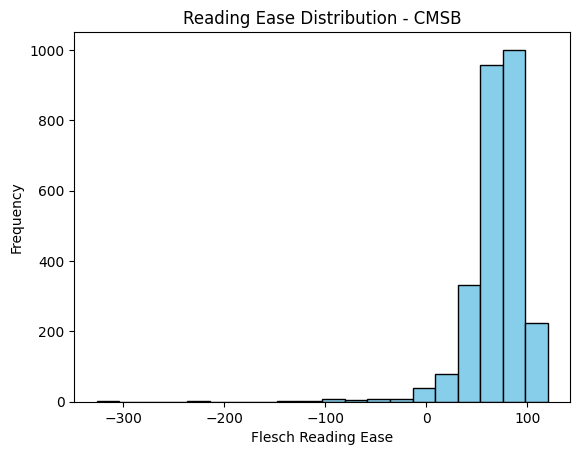

Average Flesch Reading Ease: 69.81


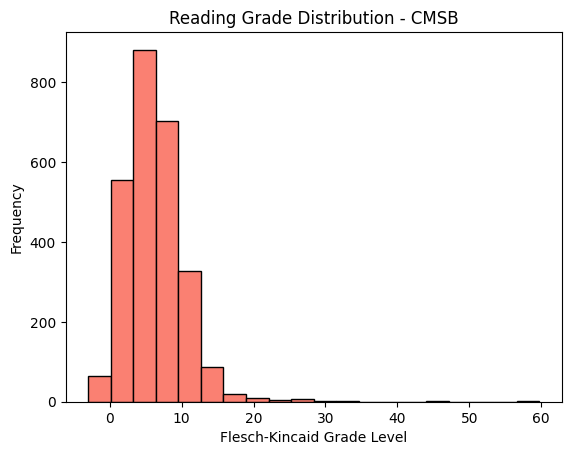

Average Flesch-Kincaid Grade Level: 6.23


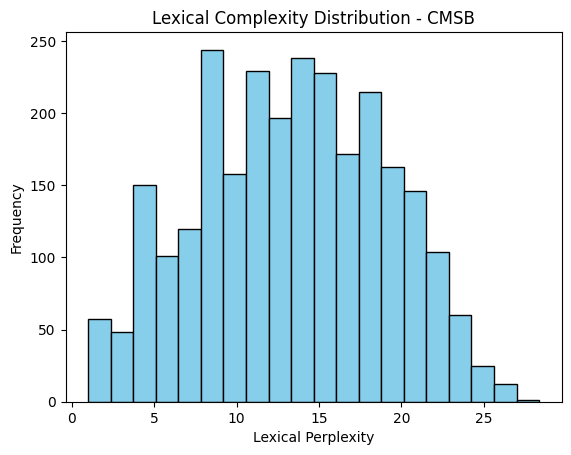

Average Lexical Perplexity: 13.34

Very confusing sentences:
MENTION2495 http://t.co/P8NuTOSWBo
MENTION1932 http://t.co/WkTuveguB0
MENTION2001 educate yourself on oppression. http://t.co/QZ0h8hM67z
PUNtastic, Colin! #mkr #hungrycampers http://t.co/8RDBv9QFjP
https://t.co/mQaSFPwoFp // MENTION3891
Women who changed the world! #InternationalWomensDay https://t.co/Vxq21l9zZO   #BeBoldForChange #ADayWithoutWomen https://t.co/w4mOaHuY4W
Anyone eliminated yet?  #mkr
MENTION3865 http://t.co/QhZmgfPWSW
MENTION1845 http://t.co/ElwRyZZhT2
literally #devops
MENTION1571 Absolutely.
Cannot unsee. http://t.co/9Tb8dBV3Da
#IDontNeedFeminism #FemFreeFriday http://t.co/PnhzjRhHqR
Nothing more #beautiful than a #woman....

#womensday #InternationalWomensDay 
#InspireThemRetweetTuesday
#IQRTG… https://t.co/442TeHJBPN
Productive weekend! 👍😘
tweetstats.hashtag.notyourshield.mention._roguestar_.rt

quickly, create a shield from the person that posted women's addresses on twitter!
Happy #InternationalWomensDa

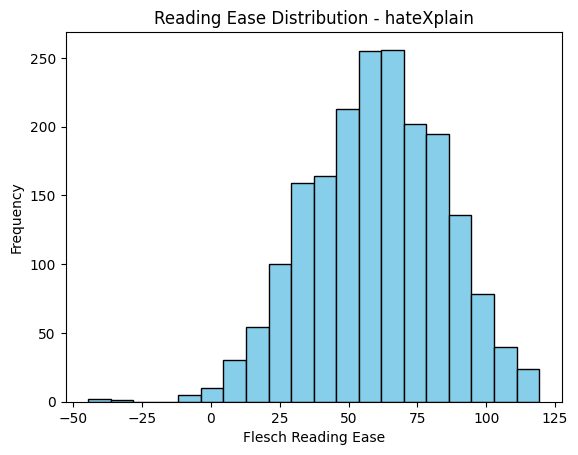

Average Flesch Reading Ease: 60.22


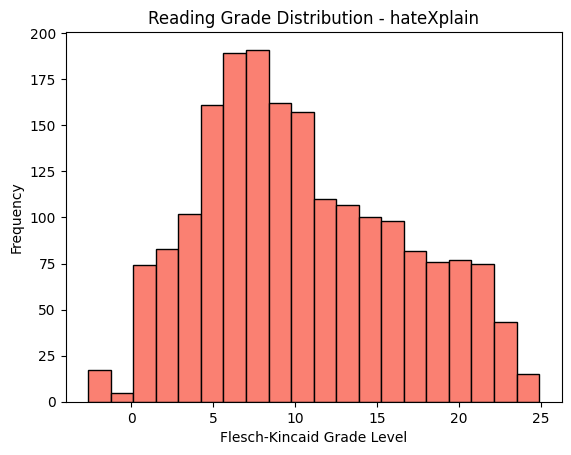

Average Flesch-Kincaid Grade Level: 10.53


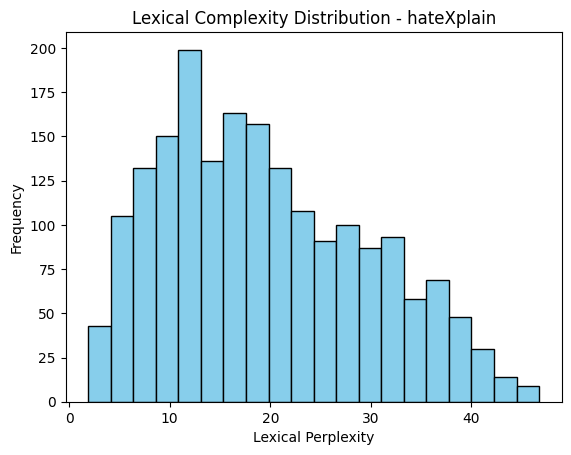

Average Lexical Perplexity: 19.58

Very confusing sentences:
jews often appropriate white identity and culture this crypsis is often selfishly motivated deceptive in the company of the goyim we jews must always identify ourselves as jews especially when espousing political opinions on israel and the middle east wear a star of david prominently
my solution would be to come out express the pain and mortification masc presenting black gay men feel on top of the already stigmatized experience of homosexuality resentment of heterosexuals the black church appeal to empathy and understanding apologize profusely
western women use vagina stereo speaker to blast unborn babies with feminist female empowerment musics of negress beyonce hag madonna breasticular katy perries slav expecting mothers enjoy cerebral classical music of tchaikovsky dvorák mussorgsky stravinsky free of vaginal intrusion
taserface ahahahahahahahahahahahaha almost as hilarious as having a nigger for president amirite
good mo

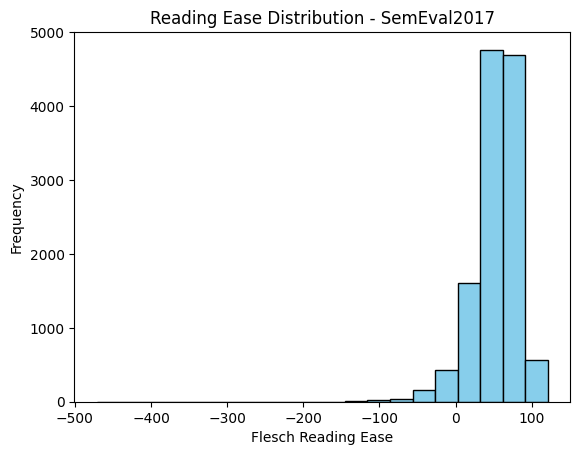

Average Flesch Reading Ease: 53.55


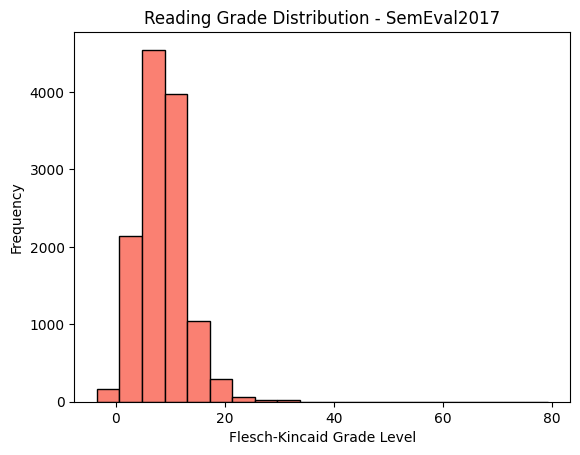

Average Flesch-Kincaid Grade Level: 8.62


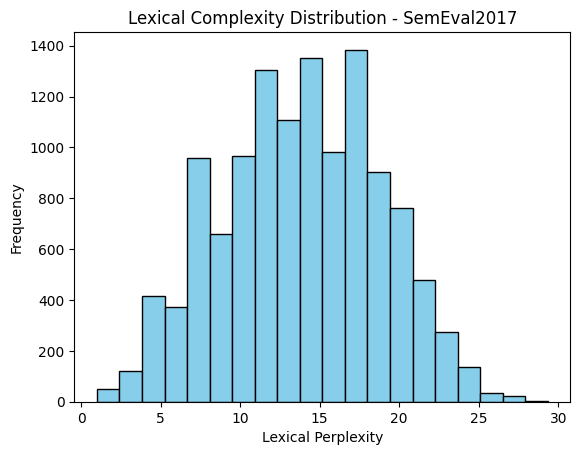

Average Lexical Perplexity: 13.81

Very confusing sentences:
China's TPP alternative lacks protection for workers, environment, information
State Undertaking Medicaid "Transformation"
What a nice and heart-warming episode <3 #ThisIsUs #LikeAllRightLetsTalkAboutTheseTwo
The best era  #3YearsofMidnightMemories #MPN #OneDirection #MtvStarsNiallHoran
Late Thanksgiving Day selfie #happyholidays #notsweaterweather…
Forbes Welcomehttps://t.co/WqplQX2Na8
leonard cohen//bobby bazini
#IsreliForces in shuhafat #refugee camp, illegally annexed #Jerusalem, shoot #Palestinian man - condition unknown. #apartheid
Alt writing: Creating anti-liberal news stories for subversion knowing conservatives will never fact check#notmypresident #UsefulNewVerbs
@user @user you're laboriously ensuring pedophillic priests are arrested, convicted, incarcerated?
#Iraq: 69,000 people displaced #Mosul #humanitarian .#Mosuloffensive #MosulOp #Iraq#ISIS#IslamicState…
@user from @user  -  #rickymartin #JardinesDeMéxico ¡Gr

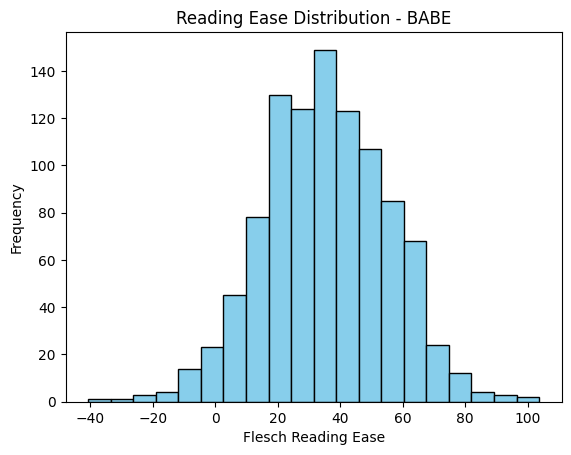

Average Flesch Reading Ease: 35.62


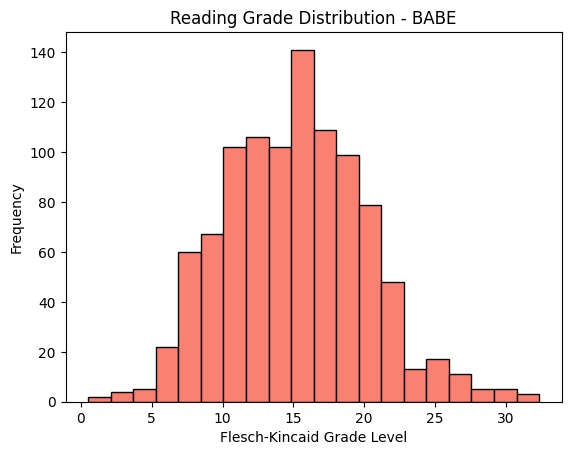

Average Flesch-Kincaid Grade Level: 15.15


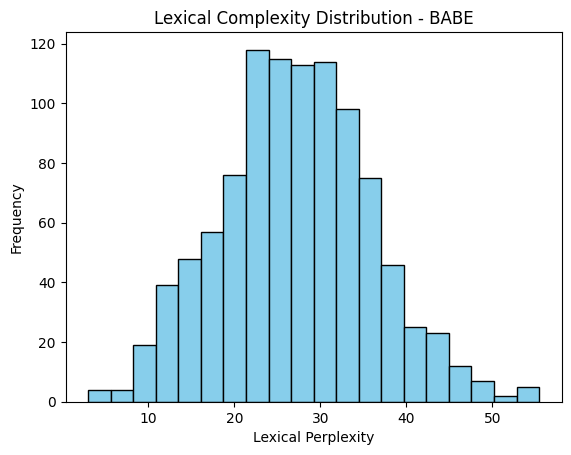

Average Lexical Perplexity: 27.11

Very confusing sentences:
A federal judge in Tucson, Arizona delivered a blow Monday to the Trump administration’s strategy of criminalizing humanitarian aid work along the southern border with her decision to overturn the convictions of four volunteers on religious freedom grounds.
A timely example is Ticketmaster, an unaccountable corporate giant whose monopoly position in the ticketing industry enables the company to charge exorbitant junk fees.
Let’s cancel institutional racism.
Capitalism, as Thomas Piketty’s Capital in the Twenty-First Century shows, relentlessly worsens wealth and income inequalities. 
Moreover, Trump's war fever is also a self-serving fascistic affirmation of his toxic hyper-masculinity and his admiration for military power and authoritarian displays generally associated with demagogues who use such displays as a tool to produce respect among their followers.
Elizabeth Warren has recalibrated her rhetoric on Medicare for All, 

In [5]:
target_dict = {"dataset": [], "reading_ease": [], "reading_grade": [], "lexical_complexity": []}
keys = ["reading_ease", "reading_grade", "lexical_complexity"]

for dataset_name in DATASETS:
    ds = load_testset(dataset_name)
    df = ds.to_pandas()

    print(f"\nStatistics for {dataset_name}")

    # Compute readability metrics
    df["reading_ease"] = df["text"].apply(textstat.flesch_reading_ease)
    df["reading_grade"] = df["text"].apply(textstat.flesch_kincaid_grade)
    df["lexical_complexity"] = df["text"].apply(lexical_perplexity)

    # Averages
    avg_reading_ease = df["reading_ease"].mean()
    avg_reading_grade = df["reading_grade"].mean()
    avg_lexical_complexity = df["lexical_complexity"].mean()

    # Store results
    target_dict["dataset"].append(dataset_name)
    for key in keys:
        target_dict[key].append(df[key].mean())

    # Plot histograms
    plt.hist(df["reading_ease"], bins=20, color="skyblue", edgecolor="black")
    plt.title(f"Reading Ease Distribution - {dataset_name}")
    plt.xlabel("Flesch Reading Ease")
    plt.ylabel("Frequency")
    plt.show()
    print(f"Average Flesch Reading Ease: {avg_reading_ease:.2f}")

    plt.hist(df["reading_grade"], bins=20, color="salmon", edgecolor="black")
    plt.title(f"Reading Grade Distribution - {dataset_name}")
    plt.xlabel("Flesch-Kincaid Grade Level")
    plt.ylabel("Frequency")
    plt.show()
    print(f"Average Flesch-Kincaid Grade Level: {avg_reading_grade:.2f}")

    plt.hist(df["lexical_complexity"], bins=20, color="skyblue", edgecolor="black")
    plt.title(f"Lexical Complexity Distribution - {dataset_name}")
    plt.xlabel("Lexical Perplexity")
    plt.ylabel("Frequency")
    plt.show()
    print(f"Average Lexical Perplexity: { avg_lexical_complexity:.2f}")

    # Show sentences with negative reading ease score (very confusing)
    weird_sentences = df[df.reading_ease < 0].text.to_list()
    if weird_sentences:
        print("\nVery confusing sentences:")
        [print(s) for s in weird_sentences]
    
    easy_sentences = df.sort_values("reading_ease", ascending=False)["text"].to_list()[:3]
    print("\nVer easy sentences:")
    [print(s) for s in easy_sentences]

target_df = pd.DataFrame(target_dict)

# Comparison

In [6]:
target_df

,dataset,reading_ease,reading_grade,lexical_complexity
0,CMSB,69.808930,6.228801,13.335708
1,hateXplain,60.219438,10.532125,19.576750
2,SemEval2017,53.548813,8.622646,13.814978
3,BABE,35.621152,15.146358,27.106635


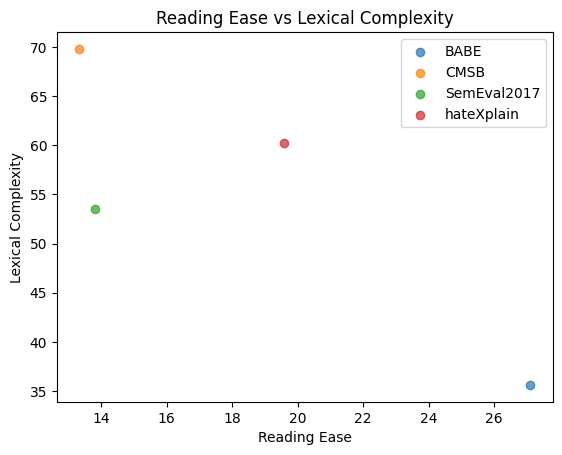

In [ ]:
for dataset, group in target_df.groupby("dataset"):
    plt.scatter(
        group["lexical_complexity"],
        group["reading_ease"],
        label=dataset,
        alpha=0.7
    )

plt.xlabel("Reading Ease")
plt.ylabel("Lexical Complexity")
plt.title("Reading Ease vs Lexical Complexity")
plt.legend()
plt.show()
